# Evaluación en prueba, calibración, residuos y robustez

Cada modelo entra con su mejor combinación de balanceo y optimizador según el bucle externo, y su
modelo final (reajustado con todo el entrenamiento) toca la prueba una sola vez. Esta página cubre la
evaluación de clasificación (§5.1), la de regresión (§5.2) y la robustez (§5.4). La etiqueta es la
del percentil 75.

In [1]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, comparacion, datos, evaluacion, graficos
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, intervalo, p_valor, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

COMPLEMENTOS = RAIZ / 'resultados' / 'complementos'
tabla = analisis.cargar_tabla()
p = datos.preparar_todo()
X_te = p['conjuntos'].X_test.sort_index()                  # orden original del archivo
y_te, y_te_c = p['y_test'].loc[X_te.index], p['conjuntos'].y_test_cont.loc[X_te.index]
pred = analisis.predecir_prueba(tabla, X_te, RAIZ / 'resultados' / 'predicciones_prueba.parquet',
                                informar=lambda s: None)
metricas = analisis.metricas_prueba(tabla, pred, y_te, y_te_c)
mejores = {t: analisis.mejores_por_modelo(tabla, t) for t in ('clasificacion', 'regresion')}
claves = {t: m.set_index('modelo')['clave'] for t, m in mejores.items()}


def pendiente(nombre):
    display(Markdown(f'*Resultado pendiente: `{nombre}` todavía no se ha calculado (lo produce `complementos.py`).*'))


display(Markdown(f'Prueba: {ent(len(y_te))} clientes, {pct(y_te.mean(), 1)} de riesgo alto.'))

Prueba: 9.745 clientes, 24,6 % de riesgo alto.

## 1. Clasificación

### Métricas de prueba

La métrica principal es el **AUC**: no depende del umbral ni de la prevalencia, y mide lo que
necesita una campaña de retención con presupuesto limitado, que es ordenar a los clientes por riesgo
para contactar primero a los de mayor riesgo. Accuracy, precisión, recall y F1 se calculan con el
umbral por defecto de 0,5, y el Brier mide la calidad de las probabilidades.

In [2]:
m_clf = metricas[metricas['tarea'] == 'clasificacion'].merge(mejores['clasificacion'][analisis.CLAVE], on=analisis.CLAVE)
m_clf = m_clf.assign(modelo=m_clf['modelo'].map(NOMBRES_MODELO)).set_index('modelo')
m_clf = m_clf[['balanceo', 'optimizador', 'metrica_cv', 'auc', 'accuracy', 'precision', 'recall', 'f1', 'brier']]
m_clf.sort_values('auc', ascending=False)

,balanceo,optimizador,metrica_cv,auc,accuracy,precision,recall,f1,brier
modelo,,,,,,,,,
EBM,class_weight,grid,0.8292,0.8289,0.7301,0.4681,0.7074,0.5634,0.1732
XGBoost,class_weight,genetica,0.8332,0.8283,0.6963,0.4476,0.9983,0.6181,0.1875
Random Forest,ninguno,genetica,0.8326,0.8260,0.7812,0.6315,0.2672,0.3755,0.1323
Árbol de decisión,class_weight,random,0.8332,0.8243,0.6964,0.4477,0.9996,0.6184,0.1690
k-NN,ninguno,genetica,0.7836,0.7874,0.7538,0.0000,0.0000,0.0000,0.1660
Regresión logística,class_weight,genetica,0.7644,0.7709,0.6791,0.4102,0.6928,0.5153,0.1977
SVM lineal,class_weight,grid,0.7641,0.7706,0.6773,0.4088,0.6965,0.5152,NaN
Naive Bayes,ninguno,grid,0.6722,0.6662,0.2847,0.2504,0.9558,0.3968,0.6600


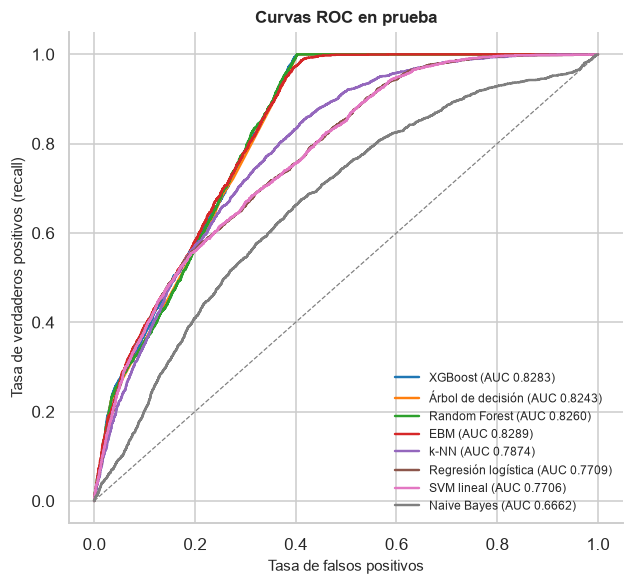

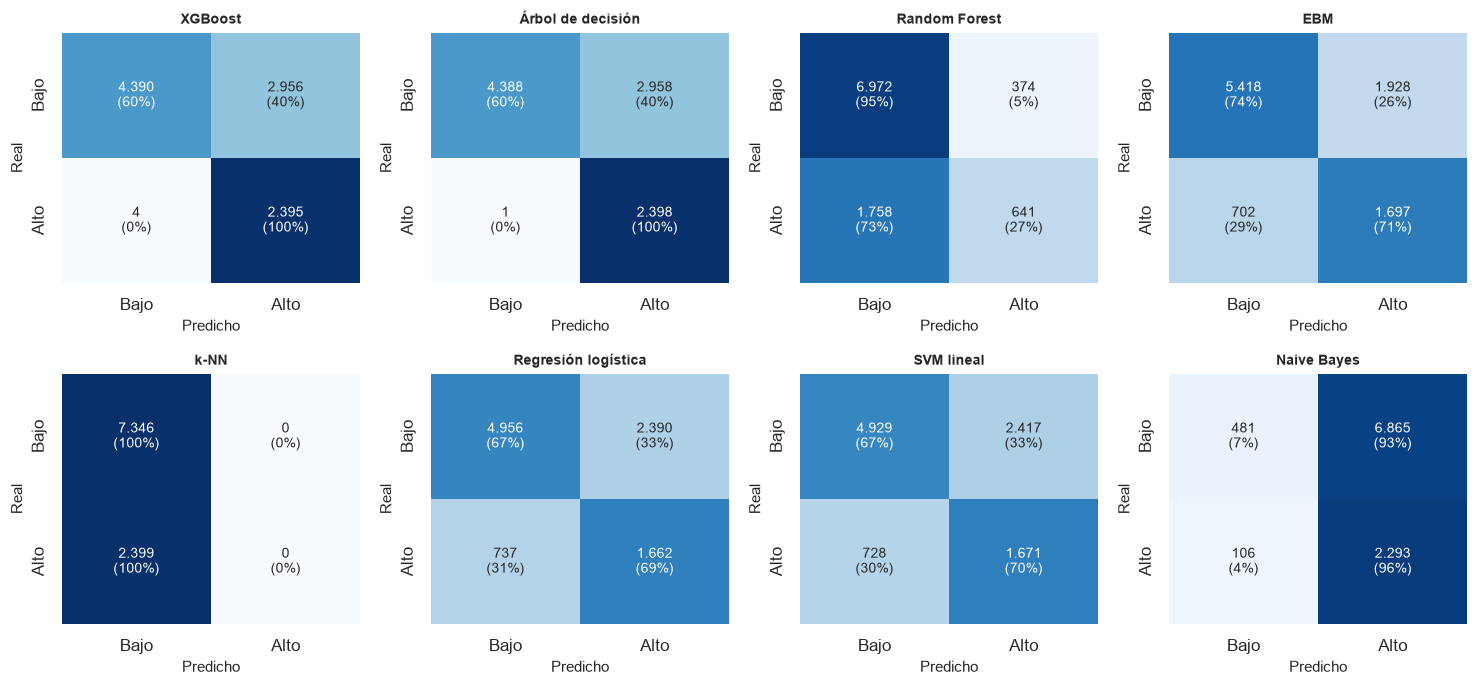

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 5.8))
graficos.curvas_roc(y_te, {NOMBRES_MODELO[m]: pred[k] for m, k in claves['clasificacion'].items()}, ax=ax)
plt.show()
modelos_clf = list(claves['clasificacion'].index)
fig, axes = plt.subplots(2, (len(modelos_clf) + 1) // 2, figsize=(3.4 * ((len(modelos_clf) + 1) // 2), 6.4))
for a, m in zip(axes.ravel(), modelos_clf):
    graficos.matriz_confusion(y_te, pred[claves['clasificacion'][m] + '__clase'], ax=a, titulo=NOMBRES_MODELO[m])
for a in axes.ravel()[len(modelos_clf):]:
    a.axis('off')
plt.tight_layout()
plt.show()

In [4]:
mejor = m_clf['auc'].idxmax()
recall_extremos = m_clf['recall'].agg(['idxmin', 'idxmax'])
display(Markdown(f"""
El AUC de prueba coincide con el de la validación anidada: {enumerar(f"{m} ({dec(r.auc)} frente a {dec(r.metrica_cv)})" for m, r in m_clf.sort_values('auc', ascending=False).head(3).iterrows())}.
Las métricas con umbral, en cambio, varían de un extremo a otro aunque el AUC sea parecido: el
recall va de {dec(m_clf['recall'].min(), 3)} ({recall_extremos['idxmin']}) a {dec(m_clf['recall'].max(), 3)}
({recall_extremos['idxmax']}). El umbral de 0,5 no significa lo mismo para todos los modelos: los
entrenados con `class_weight` desplazan sus probabilidades hacia arriba y casi todo cliente lo
supera, y los entrenados sin balanceo rara vez lo alcanzan con un 25 % de positivos. Por eso el
umbral se fija aparte (abajo) y las probabilidades se calibran.
"""))


El AUC de prueba coincide con el de la validación anidada: EBM (0,8289 frente a 0,8292), XGBoost (0,8283 frente a 0,8332) y Random Forest (0,8260 frente a 0,8326).
Las métricas con umbral, en cambio, varían de un extremo a otro aunque el AUC sea parecido: el
recall va de 0,000 (k-NN) a 1,000
(Árbol de decisión). El umbral de 0,5 no significa lo mismo para todos los modelos: los
entrenados con `class_weight` desplazan sus probabilidades hacia arriba y casi todo cliente lo
supera, y los entrenados sin balanceo rara vez lo alcanzan con un 25 % de positivos. Por eso el
umbral se fija aparte (abajo) y las probabilidades se calibran.


### El umbral de operación

En la práctica, una campaña de retención contacta a una fracción fija de clientes. Si se contacta al
25 % de mayor riesgo (la prevalencia de la etiqueta), el umbral de cada modelo es su percentil 75 de
puntaje, y la comparación entre modelos se vuelve justa.

In [5]:
filas = []
n_contactar = int(round(0.25 * len(y_te)))
desempate = np.random.default_rng(42).random(len(y_te))   # los empates de puntaje se rompen al azar
for m, k in claves['clasificacion'].items():
    s = pred[k].to_numpy()
    contactados = np.zeros(len(s), dtype=bool)
    contactados[np.lexsort((desempate, -s))[:n_contactar]] = True
    vp = int((contactados & (y_te.to_numpy() == 1)).sum())
    filas.append({'modelo': NOMBRES_MODELO[m], 'precisión en el 25 % contactado': vp / contactados.sum(),
                  'recall (fracción de la fuga que se captura)': vp / int(y_te.sum()),
                  'lift frente a contactar al azar': (vp / contactados.sum()) / y_te.mean()})
operacion = pd.DataFrame(filas).set_index('modelo').sort_values('recall (fracción de la fuga que se captura)', ascending=False)
operacion

,precisión en el 25 % contactado,recall (fracción de la fuga que se captura),lift frente a contactar al azar
modelo,,,
EBM,0.5041,0.5119,2.0477
Regresión logística,0.5029,0.5106,2.0427
SVM lineal,0.5029,0.5106,2.0427
XGBoost,0.5025,0.5102,2.0411
k-NN,0.5004,0.5081,2.0327
Árbol de decisión,0.4947,0.5023,2.0094
Random Forest,0.4860,0.4935,1.9744
Naive Bayes,0.4019,0.4081,1.6325


In [6]:
top = operacion.iloc[0]
display(Markdown(f"""
Se contacta exactamente a {ent(n_contactar)} clientes con cada modelo (los empates de puntaje, frecuentes en
el árbol, se rompen al azar). Contactando al 25 % de mayor riesgo según {operacion.index[0]}, la campaña llegaría al
{pct(top['recall (fracción de la fuga que se captura)'], 0)} de los clientes de riesgo alto, con una precisión del
{pct(top['precisión en el 25 % contactado'], 0)}: {dec(top['lift frente a contactar al azar'], 2)} veces lo que se obtendría eligiendo al azar.
Con la misma capacidad, {operacion.index[-1]} capturaría el {pct(operacion.iloc[-1]['recall (fracción de la fuga que se captura)'], 0)}.
"""))


Se contacta exactamente a 2.436 clientes con cada modelo (los empates de puntaje, frecuentes en
el árbol, se rompen al azar). Contactando al 25 % de mayor riesgo según EBM, la campaña llegaría al
51 % de los clientes de riesgo alto, con una precisión del
50 %: 2,05 veces lo que se obtendría eligiendo al azar.
Con la misma capacidad, Naive Bayes capturaría el 41 %.


### Calibración

Una probabilidad está calibrada si, entre los clientes a los que el modelo asigna 0,3, el 30 % es de
riesgo alto. Importa si las probabilidades se van a usar como tales (por ejemplo, para estimar la
pérdida esperada de clientes). Se mide con el diagrama de confiabilidad, el **Brier** (error
cuadrático de la probabilidad) y el **ECE** (distancia media ponderada entre probabilidad anunciada y
frecuencia observada, con 10 intervalos). Cuando hace falta se recalibra con **Platt** (una logística
sobre el puntaje) o con regresión **isotónica** (una función monótona por tramos), ajustadas **solo con
predicciones fuera de pliegue del entrenamiento** y aplicadas después a la prueba.

brier                             ece            \
version              Platt isotónica sin recalibrar  Platt isotónica   
modelo                                                                 
EBM                 0.1438    0.1338         0.1732 0.0790    0.0060   
Naive Bayes         0.1784    0.1736         0.6600 0.0380    0.0041   
Random Forest       0.1325    0.1307         0.1323 0.0281    0.0029   
Regresión logística 0.1537    0.1521         0.1977 0.0319    0.0064   
SVM lineal          0.1539    0.1523            NaN 0.0320    0.0074   
XGBoost             0.1318    0.1305         0.1875 0.0263    0.0075   
k-NN                0.1523    0.1510         0.1660 0.0300    0.0082   
Árbol de decisión   0.1309    0.1308         0.1690 0.0105    0.0100   

                                    
version             sin recalibrar  
modelo                              
EBM                         0.1698  
Naive Bayes                 0.6824  
Random Forest               0.0274  
Regresión logística         0.1993  
SVM lineal                     NaN  
XGBoost                     0.2201  
k-NN                        0.0837  
Árbol de decisión           0.1442

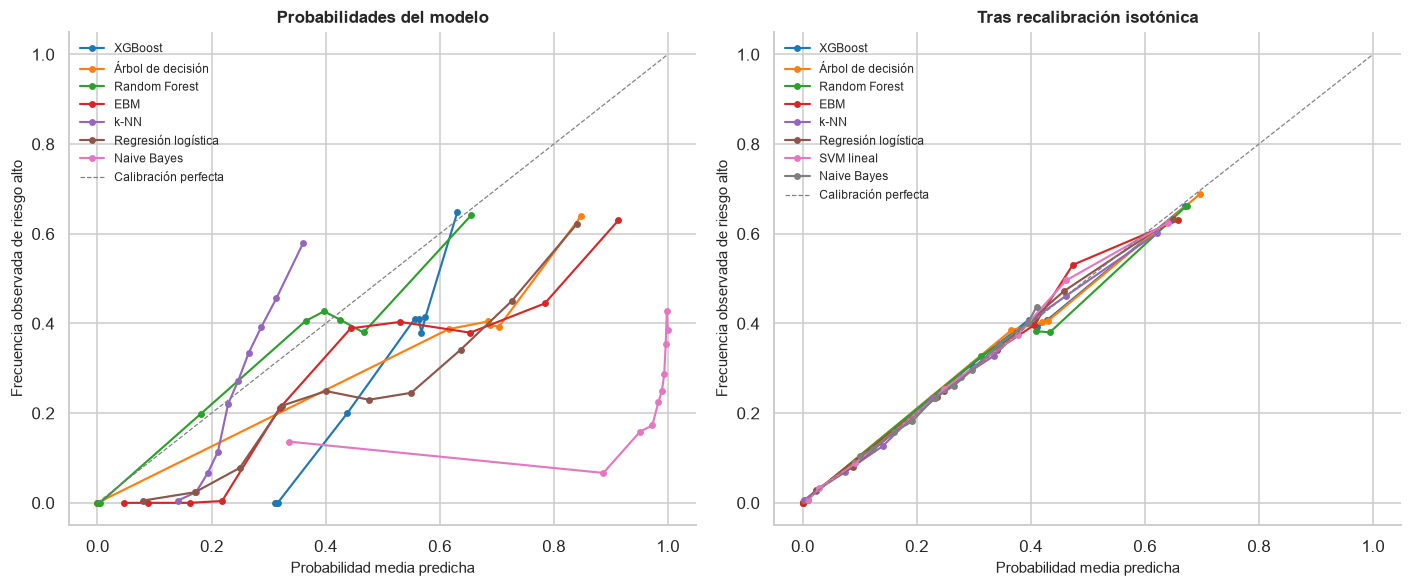


Sin recalibrar, el ECE va de 0,027 (Random Forest) a 0,682 (Naive Bayes). Los peor calibrados
son Naive Bayes (0,682; sin balanceo), XGBoost (0,220; con class_weight), Regresión logística (0,199; con class_weight) y EBM (0,170; con class_weight): los modelos entrenados con `class_weight`
desplazan sus probabilidades hacia arriba a propósito, y Naive Bayes, que supone independencia entre 78
variables, produce probabilidades extremas. La recalibración isotónica, ajustada solo con predicciones
fuera de pliegue del entrenamiento, reduce el ECE de todos
(queda entre 0,003 y 0,010) y apenas mueve el AUC (como mucho
0,0025 frente a Platt), porque es monótona: corrige las probabilidades sin cambiar el orden de
los clientes. El SVM lineal no da probabilidades (solo una función de decisión): Platt e isotónica son las que convierten su puntaje en probabilidad.


In [7]:
if (COMPLEMENTOS / 'calibracion.csv').exists():
    cal = pd.read_csv(COMPLEMENTOS / 'calibracion.csv')
    cal['modelo'] = cal['modelo'].map(NOMBRES_MODELO)
    display(cal.pivot_table(index='modelo', columns='version', values=['brier', 'ece']).round(4))
    probas = pd.read_parquet(COMPLEMENTOS / 'calibracion_prueba.parquet')
    fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
    sin = {NOMBRES_MODELO[m]: probas[f'{k}__sin recalibrar'] for m, k in claves['clasificacion'].items()
           if f'{k}__sin recalibrar' in probas}
    iso = {NOMBRES_MODELO[m]: probas[f'{k}__isotónica'] for m, k in claves['clasificacion'].items()}
    graficos.diagrama_confiabilidad(probas['y_bin'], sin, ax=ax[0], titulo='Probabilidades del modelo')
    graficos.diagrama_confiabilidad(probas['y_bin'], iso, ax=ax[1], titulo='Tras recalibración isotónica')
    plt.tight_layout()
    plt.show()
    piv = cal.pivot_table(index='modelo', columns='version', values='ece')
    sin = piv['sin recalibrar'].dropna()
    mejora = (sin - piv['isotónica'].reindex(sin.index))
    sin_prob = [m for m in piv.index if m not in sin.index]
    bal = cal.drop_duplicates('modelo').set_index('modelo')['balanceo']
    peores = sin.sort_values(ascending=False).head(4)
    auc_cambio = cal.pivot_table(index='modelo', columns='version', values='auc')
    display(Markdown(f"""
Sin recalibrar, el ECE va de {dec(sin.min(), 3)} ({sin.idxmin()}) a {dec(sin.max(), 3)} ({sin.idxmax()}). Los peor calibrados
son {enumerar(f"{m} ({dec(v, 3)}; " + ('sin balanceo' if bal[m] == 'ninguno' else f'con {bal[m]}') + ")" for m, v in peores.items())}: los modelos entrenados con `class_weight`
desplazan sus probabilidades hacia arriba a propósito, y Naive Bayes, que supone independencia entre 78
variables, produce probabilidades extremas. La recalibración isotónica, ajustada solo con predicciones
fuera de pliegue del entrenamiento, {'reduce el ECE de todos' if (mejora > 0).all() else 'reduce el ECE de todos salvo ' + enumerar(mejora[mejora <= 0].index)}
(queda entre {dec(piv['isotónica'].min(), 3)} y {dec(piv['isotónica'].max(), 3)}) y apenas mueve el AUC (como mucho
{dec((auc_cambio['isotónica'] - auc_cambio['Platt']).abs().max(), 4)} frente a Platt), porque es monótona: corrige las probabilidades sin cambiar el orden de
los clientes.{(' El ' + enumerar(sin_prob) + (' no da' if len(sin_prob) == 1 else ' no dan') + ' probabilidades (solo una función de decisión): Platt e isotónica son las que convierten su puntaje en probabilidad.') if sin_prob else ''}
"""))
else:
    pendiente('calibracion.csv')

### El balanceo, medido en prueba

In [8]:
clf_todas = metricas[metricas['tarea'] == 'clasificacion']
mejor_por_bal = clf_todas.loc[clf_todas.groupby(['modelo', 'balanceo'])['metrica_cv'].idxmax()]
bal_auc = mejor_por_bal.pivot(index='modelo', columns='balanceo', values='auc')
bal_rec = mejor_por_bal.pivot(index='modelo', columns='balanceo', values='recall')
bal_auc.index = bal_rec.index = [NOMBRES_MODELO[m] for m in bal_auc.index]
display(bal_auc.round(4))
display(bal_rec.round(3))
d_smote = (bal_auc['smote'] - bal_auc['ninguno']).dropna()
d_cw = (bal_auc['class_weight'] - bal_auc['ninguno']).dropna()
display(Markdown(f"""
En prueba, `class_weight` cambia el AUC entre {dec(d_cw.min(), 4, True)} y {dec(d_cw.max(), 4, True)} frente a no balancear, y
SMOTE entre {dec(d_smote.min(), 4, True)} ({d_smote.idxmin()}) y {dec(d_smote.max(), 4, True)} ({d_smote.idxmax()}): lo baja en
{int((d_smote < 0).sum())} de {len(d_smote)} modelos{('; las excepciones (' if (d_smote > 0).sum() > 1 else '; la excepción (') + enumerar(d_smote[d_smote > 0].index) + (') son de milésimas' if (d_smote > 0).sum() > 1 else ') es de milésimas') + ', dentro de la variabilidad de la prueba' if (d_smote > 0).any() else ''}.
Lo que cambia de verdad es el recall con el umbral de 0,5. El balanceo, en este problema, es una forma
de elegir el punto de operación, no de mejorar el modelo.
"""))

balanceo,adasyn,class_weight,ninguno,smote
Árbol de decisión,0.8206,0.8243,0.8232,0.8288
EBM,0.8265,0.8289,0.8261,0.8253
k-NN,0.7817,NaN,0.7874,0.7767
Regresión logística,0.7708,0.7709,0.7710,0.7706
Naive Bayes,0.6185,0.6662,0.6662,0.6167
Random Forest,0.8263,0.8269,0.8260,0.8272
SVM lineal,0.7701,0.7706,0.7697,0.7699
XGBoost,0.8273,0.8283,0.8280,0.8265


balanceo,adasyn,class_weight,ninguno,smote
Árbol de decisión,0.5240,1.0000,0.2380,0.4640
EBM,0.3440,0.7070,0.3220,0.3410
k-NN,0.8760,NaN,0.0000,0.8790
Regresión logística,0.6800,0.6930,0.2850,0.6800
Naive Bayes,0.9120,0.9600,0.9560,0.9160
Random Forest,0.4640,0.9920,0.2670,0.3880
SVM lineal,0.6850,0.6970,0.2310,0.6850
XGBoost,0.3220,0.9980,0.0000,0.3260



En prueba, `class_weight` cambia el AUC entre −0,0001 y +0,0029 frente a no balancear, y
SMOTE entre −0,0496 (Naive Bayes) y +0,0055 (Árbol de decisión): lo baja en
5 de 8 modelos; las excepciones (Árbol de decisión, Random Forest y SVM lineal) son de milésimas, dentro de la variabilidad de la prueba.
Lo que cambia de verdad es el recall con el umbral de 0,5. El balanceo, en este problema, es una forma
de elegir el punto de operación, no de mejorar el modelo.


## 2. Regresión

### Métricas de prueba con intervalos bootstrap BCa

In [9]:
pron = {m: pred[k].to_numpy() for m, k in claves['regresion'].items()}
int_reg = comparacion.intervalos_regresion(y_te_c, pron)
int_reg.index = [NOMBRES_MODELO[m] for m in int_reg.index]
cv_reg = mejores['regresion'].set_index('modelo')['metrica']
int_reg.insert(0, 'RMSE validación anidada', [cv_reg[m] for m in pron])
int_reg.sort_values('rmse')

,RMSE validación anidada,rmse,rmse_ic_inf,rmse_ic_sup,mae,mae_ic_inf,mae_ic_sup,r2,r2_ic_inf,r2_ic_sup
XGBoost,0.0590,0.0592,0.0584,0.0600,0.0471,0.0464,0.0478,0.2182,0.2031,0.2315
EBM,0.0590,0.0593,0.0585,0.0601,0.0472,0.0465,0.0480,0.2161,0.2008,0.2300
Random Forest,0.0592,0.0593,0.0585,0.0601,0.0473,0.0466,0.0480,0.2146,0.1995,0.2283
Árbol de decisión,0.0593,0.0594,0.0586,0.0603,0.0475,0.0468,0.0482,0.2112,0.1960,0.2255
Lasso,0.0618,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1511,0.1381,0.1639
Ridge,0.0618,0.0617,0.0608,0.0625,0.0507,0.0500,0.0514,0.1509,0.1377,0.1637
SVR lineal,0.0618,0.0617,0.0609,0.0626,0.0507,0.0500,0.0514,0.1499,0.1365,0.1629
k-NN,0.0634,0.0632,0.0624,0.0641,0.0511,0.0504,0.0519,0.1080,0.1011,0.1147


### Entrenamiento, validación y prueba

La guía pide graficar las predicciones sobre los tres conjuntos. Para entrenamiento se usan las
predicciones del modelo final sobre los clientes con los que se ajustó; para validación, las
predicciones fuera de pliegue (cada cliente de entrenamiento predicho por un modelo que no lo vio); y
la prueba. Los clientes se agrupan en 20 grupos de igual tamaño según el pronóstico.

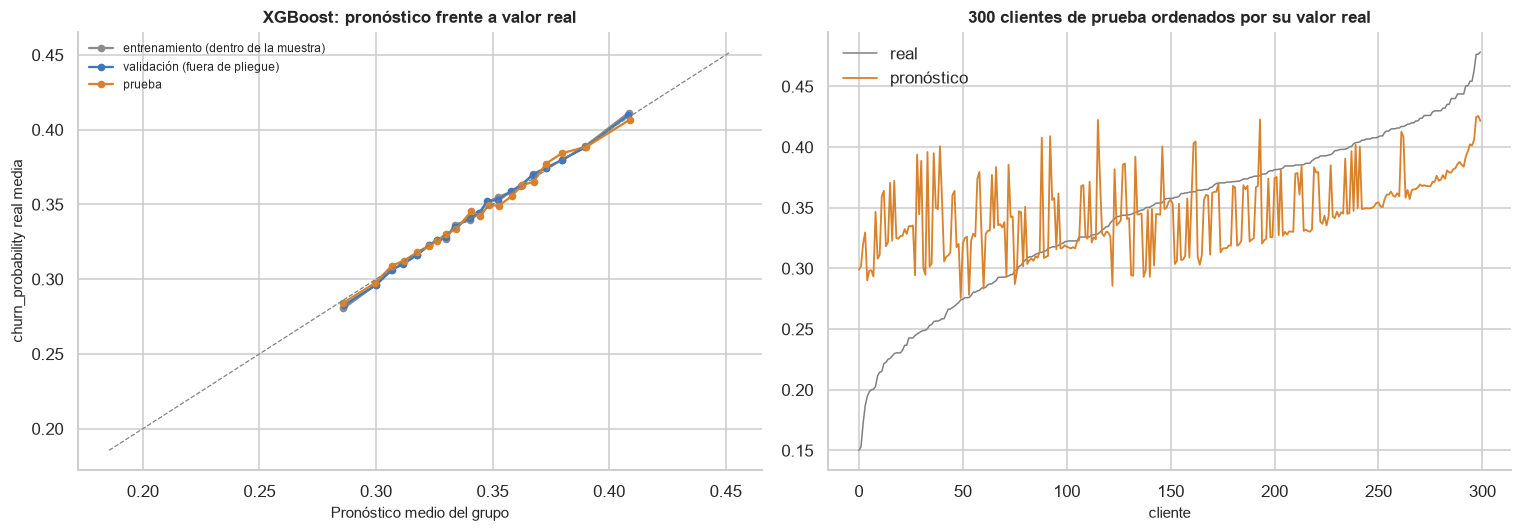

,rmse,mae,r2
conjunto,,,
entrenamiento (dentro de la muestra),0.0587,0.0467,0.2343
validación (fuera de pliegue),0.0590,0.0469,0.2280
prueba,0.0592,0.0471,0.2182



El R² cae de 0,234 dentro de la muestra a 0,228 fuera de pliegue y 0,218
en prueba: el modelo se ajusta algo más a los clientes que vio, pero validación y prueba coinciden, de
modo que la estimación de la validación es fiable. El panel derecho muestra el límite de la tarea: el
pronóstico sigue la tendencia pero se comprime hacia la media, porque la mayor parte de la variación de
`churn_probability` la explica `active_products`, que el modelo no ve.


In [10]:
mejor_r = mejores['regresion'].iloc[0]
if (COMPLEMENTOS / 'fuera_de_pliegue.parquet').exists():
    fdp = pd.read_parquet(COMPLEMENTOS / 'fuera_de_pliegue.parquet')
    k = mejor_r['clave']
    conjuntos = {'entrenamiento (dentro de la muestra)': (fdp['y_cont'], fdp[f'{k}__entrenamiento']),
                 'validación (fuera de pliegue)': (fdp['y_cont'], fdp[f'{k}__fuera_de_pliegue']),
                 'prueba': (y_te_c, pred[k])}
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    filas = []
    for (nombre, (y, yh)), color in zip(conjuntos.items(), ('#8c8c8c', '#3d78bf', '#d9822b')):
        y, yh = np.asarray(y), np.asarray(yh)
        orden = np.argsort(yh)
        grupos = np.array_split(orden, 20)
        ax[0].plot([yh[g].mean() for g in grupos], [y[g].mean() for g in grupos], marker='o', ms=4, color=color, label=nombre)
        filas.append({'conjunto': nombre, **evaluacion.metricas_regresion(y, yh)})
    lim = [float(y_te_c.quantile(0.02)), float(y_te_c.quantile(0.98))]
    ax[0].plot(lim, lim, ls='--', color='grey', lw=0.8)
    ax[0].set_xlabel('Pronóstico medio del grupo')
    ax[0].set_ylabel('churn_probability real media')
    ax[0].set_title(f'{NOMBRES_MODELO[mejor_r["modelo"]]}: pronóstico frente a valor real')
    ax[0].legend(frameon=False, fontsize=8)
    muestra = np.random.default_rng(42).choice(len(y_te_c), 300, replace=False)
    orden = muestra[np.argsort(y_te_c.to_numpy()[muestra])]
    ax[1].plot(y_te_c.to_numpy()[orden], color='grey', lw=1, label='real')
    ax[1].plot(pred[k].to_numpy()[orden], color='#d9822b', lw=1.2, label='pronóstico')
    ax[1].set_title('300 clientes de prueba ordenados por su valor real')
    ax[1].set_xlabel('cliente')
    ax[1].legend(frameon=False)
    plt.tight_layout()
    plt.show()
    tres = pd.DataFrame(filas).set_index('conjunto')
    display(tres)
    display(Markdown(f"""
El R² cae de {dec(tres.iloc[0]['r2'], 3)} dentro de la muestra a {dec(tres.iloc[1]['r2'], 3)} fuera de pliegue y {dec(tres.iloc[2]['r2'], 3)}
en prueba: el modelo se ajusta algo más a los clientes que vio, pero validación y prueba coinciden, de
modo que la estimación de la validación es fiable. El panel derecho muestra el límite de la tarea: el
pronóstico sigue la tendencia pero se comprime hacia la media, porque la mayor parte de la variación de
`churn_probability` la explica `active_products`, que el modelo no ve.
"""))
else:
    pendiente('fuera_de_pliegue.parquet')

### Diagnóstico de los residuos

La guía (§5.2.2 y Cuadro 3) pide verificar los supuestos sobre los residuos de cada modelo de
regresión: White (¿varianza constante?), BDS (¿residuos independientes e idénticamente
distribuidos?), la ACF con Ljung-Box (¿autocorrelación?) y la normalidad. Los residuos se toman en el
orden original del archivo de clientes. Primero, la tabla resumen de todos los modelos; después, el
detalle gráfico del mejor modelo y del Lasso de la Entrega 2.

In [11]:
cuadro = []
for m, k in claves['regresion'].items():
    d_m = evaluacion.diagnostico_residuos(y_te_c, pron[m])
    met = evaluacion.metricas_regresion(y_te_c.to_numpy(), pron[m])
    cuadro.append({'modelo': NOMBRES_MODELO[m], 'RMSE': met['rmse'], 'MAE': met['mae'], 'R²': met['r2'],
                   'p White': d_m.loc['White', 'p'], 'p BDS (dim. 2)': d_m.loc['BDS, dimensión 2 (3000 residuos)', 'p'],
                   'p Ljung-Box (10)': d_m.loc['Ljung-Box, 10 retardos', 'p'], 'p Jarque-Bera': d_m.loc['Jarque-Bera', 'p'],
                   'asimetría': d_m.loc['asimetría', 'estadistico']})
cuadro3 = pd.DataFrame(cuadro).set_index('modelo').sort_values('RMSE')
cuadro3

,RMSE,MAE,R²,p White,p BDS (dim. 2),p Ljung-Box (10),p Jarque-Bera,asimetría
modelo,,,,,,,,
XGBoost,0.0592,0.0471,0.2182,0.6383,0.4378,0.8112,0.0000,-0.9051
EBM,0.0593,0.0472,0.2161,0.6669,0.5456,0.8074,0.0000,-0.9016
Random Forest,0.0593,0.0473,0.2146,0.6310,0.5487,0.7554,0.0000,-0.8957
Árbol de decisión,0.0594,0.0475,0.2112,0.7900,0.6031,0.7201,0.0000,-0.8910
Lasso,0.0617,0.0507,0.1511,0.3907,0.6138,0.0000,0.0000,-0.8001
Ridge,0.0617,0.0507,0.1509,0.6149,0.6500,0.0000,0.0000,-0.8018
SVR lineal,0.0617,0.0507,0.1499,0.6022,0.5969,0.0000,0.0000,-0.8006
k-NN,0.0632,0.0511,0.1080,0.5412,0.3275,0.0000,0.0000,-0.7332


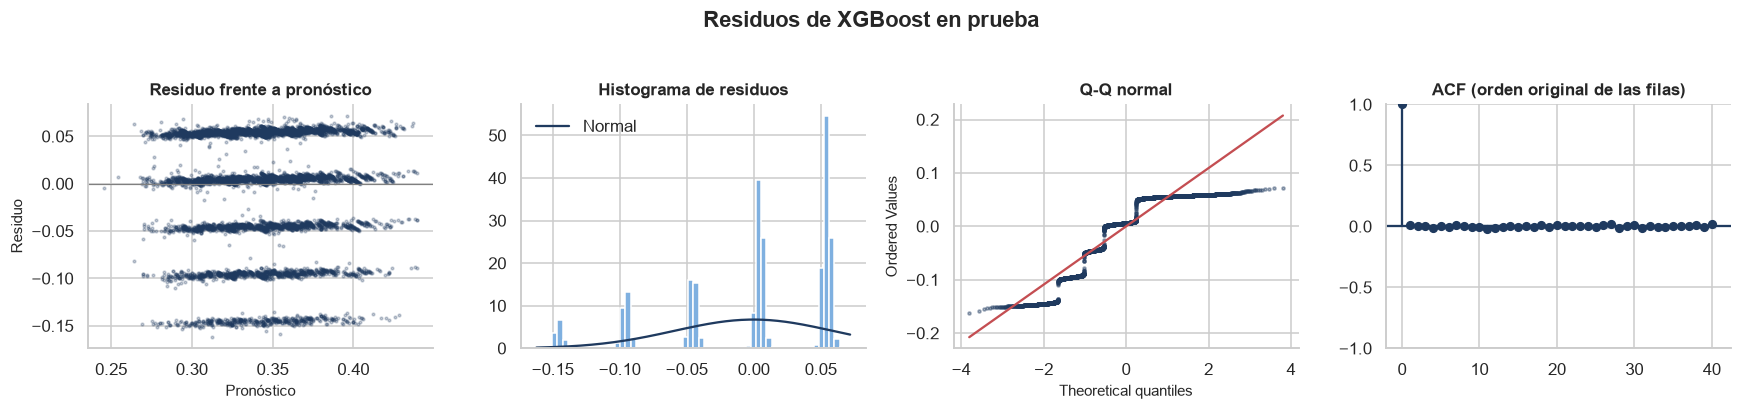

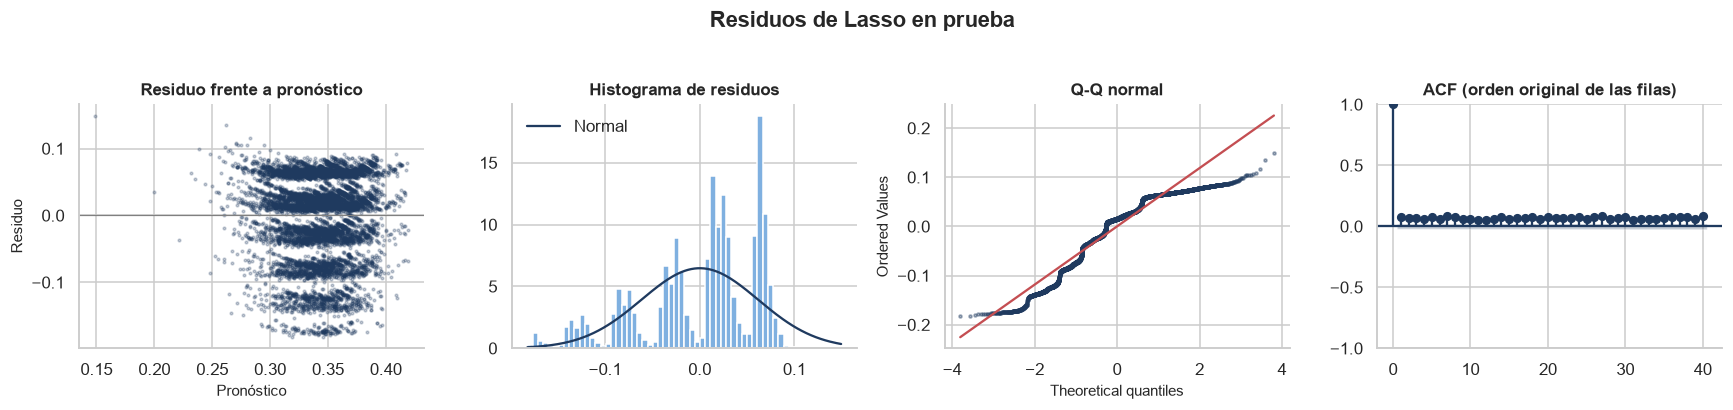

XGBoost  \
                                                      hipótesis nula   
prueba                                                                 
White                             varianza constante de los residuos   
BDS, dimensión 2 (3000 residuos)                     residuos i.i.d.   
BDS, dimensión 3 (3000 residuos)                     residuos i.i.d.   
Ljung-Box, 10 retardos                           sin autocorrelación   
Ljung-Box, 20 retardos                           sin autocorrelación   
Jarque-Bera                                               normalidad   
D'Agostino-Pearson                                        normalidad   
asimetría                                          0 si es simétrica   
curtosis en exceso                                    0 si es normal   

                                                     \
                                 estadistico      p   
prueba                                                
White                                 0.8980 0.6383   
BDS, dimensión 2 (3000 residuos)     -0.7758 0.4378   
BDS, dimensión 3 (3000 residuos)     -0.9460 0.3442   
Ljung-Box, 10 retardos                6.0485 0.8112   
Ljung-Box, 20 retardos               14.0153 0.8297   
Jarque-Bera                       1,340.1656 0.0000   
D'Agostino-Pearson                1,002.7799 0.0000   
asimetría                            -0.9051    NaN   
curtosis en exceso                   -0.1531    NaN   

                                                               Lasso  \
                                                      hipótesis nula   
prueba                                                                 
White                             varianza constante de los residuos   
BDS, dimensión 2 (3000 residuos)                     residuos i.i.d.   
BDS, dimensión 3 (3000 residuos)                     residuos i.i.d.   
Ljung-Box, 10 retardos                           sin autocorrelación   
Ljung-Box, 20 retardos                           sin autocorrelación   
Jarque-Bera                                               normalidad   
D'Agostino-Pearson                                        normalidad   
asimetría                                          0 si es simétrica   
curtosis en exceso                                    0 si es normal   

                                                     
                                 estadistico      p  
prueba                                               
White                                 1.8795 0.3907  
BDS, dimensión 2 (3000 residuos)     -0.5046 0.6138  
BDS, dimensión 3 (3000 residuos)     -0.7166 0.4736  
Ljung-Box, 10 retardos              466.4354 0.0000  
Ljung-Box, 20 retardos              881.8707 0.0000  
Jarque-Bera                       1,046.1670 0.0000  
D'Agostino-Pearson                  822.9394 0.0000  
asimetría                            -0.8001    NaN  
curtosis en exceso                   -0.1270    NaN

In [12]:
diagnosticos = {}
for m in [mejor_r['modelo'], 'lasso']:
    diagnosticos[NOMBRES_MODELO[m]] = evaluacion.diagnostico_residuos(y_te_c, pron[m])
    graficos.panel_residuos(y_te_c, pron[m], titulo=f'Residuos de {NOMBRES_MODELO[m]} en prueba')
    plt.show()
pd.concat(diagnosticos, axis=1)

In [13]:
d = diagnosticos[NOMBRES_MODELO[mejor_r['modelo']]]
rechaza = lambda prueba: d.loc[prueba, 'p'] < 0.05
het = cuadro3[cuadro3['p White'] < 0.05].index.tolist()
dep = cuadro3[(cuadro3['p BDS (dim. 2)'] < 0.05) | (cuadro3['p Ljung-Box (10)'] < 0.05)].index.tolist()
display(Markdown(f"""
En el conjunto de modelos, White rechaza la varianza constante en {len(het)} de {len(cuadro3)}
({enumerar(het) if het else 'ninguno'}) y BDS o Ljung-Box detectan dependencia en {len(dep)}
({enumerar(dep) if dep else 'ninguno'}){': son los modelos que no captan bien el efecto no lineal de la edad, y su residuo conserva parte de la estructura por cohortes con que está ordenado el archivo' if dep else ''}. La normalidad se rechaza en todos: el residuo de cualquier
modelo hereda la mezcla por niveles de `active_products`. Para {NOMBRES_MODELO[mejor_r['modelo']]}:

- **Heterocedasticidad.** White {'rechaza' if rechaza('White') else 'no rechaza'} la varianza constante ({p_valor(d.loc['White', 'p'])}). {'La dispersión del residuo cambia con el nivel pronosticado: los intervalos de predicción deberían depender del riesgo, y el RMSE promedia errores de magnitud distinta en cada tramo.' if rechaza('White') else ''}
- **Dependencia.** Ljung-Box con 10 retardos {'rechaza' if rechaza('Ljung-Box, 10 retardos') else 'no rechaza'} la ausencia de autocorrelación
  ({p_valor(d.loc['Ljung-Box, 10 retardos', 'p'])}) y BDS {'rechaza' if rechaza('BDS, dimensión 2 (3000 residuos)') else 'no rechaza'} la independencia
  ({p_valor(d.loc['BDS, dimensión 2 (3000 residuos)', 'p'])}). Los clientes no forman una serie temporal, pero el archivo está
  ordenado por cohortes de edad (sección de datos), así que una dependencia en este orden indicaría
  que el modelo deja sin explicar algo propio de cada cohorte. {'No es el caso: el modelo capta el efecto de la cohorte y lo que queda no se agrupa por bloques.' if not (rechaza('Ljung-Box, 10 retardos') or rechaza('BDS, dimensión 2 (3000 residuos)')) else 'Es lo que ocurre: los residuos de clientes vecinos se parecen más de lo que lo harían al azar.'}
- **Normalidad.** Jarque-Bera {'rechaza' if rechaza('Jarque-Bera') else 'no rechaza'} ({p_valor(d.loc['Jarque-Bera', 'p'])}); asimetría
  {dec(d.loc['asimetría', 'estadistico'], 2)} y curtosis en exceso {dec(d.loc['curtosis en exceso', 'estadistico'], 2)}. Con casi 10.000 residuos,
  cualquier desviación pequeña es significativa; lo relevante es su forma: el residuo hereda la
  distribución por escalones de `active_products`, una mezcla de cinco componentes que ninguna
  variable observable separa.

Ninguna de estas propiedades invalida el RMSE como medida de error, pero sí los intervalos de
predicción basados en normalidad: si se necesitaran, habría que construirlos con métodos que no la
supongan (por ejemplo, regresión cuantílica o *conformal prediction*).
"""))


En el conjunto de modelos, White rechaza la varianza constante en 0 de 8
(ninguno) y BDS o Ljung-Box detectan dependencia en 4
(Lasso, Ridge, SVR lineal y k-NN): son los modelos que no captan bien el efecto no lineal de la edad, y su residuo conserva parte de la estructura por cohortes con que está ordenado el archivo. La normalidad se rechaza en todos: el residuo de cualquier
modelo hereda la mezcla por niveles de `active_products`. Para XGBoost:

- **Heterocedasticidad.** White no rechaza la varianza constante (p = 0,638). 
- **Dependencia.** Ljung-Box con 10 retardos no rechaza la ausencia de autocorrelación
  (p = 0,811) y BDS no rechaza la independencia
  (p = 0,438). Los clientes no forman una serie temporal, pero el archivo está
  ordenado por cohortes de edad (sección de datos), así que una dependencia en este orden indicaría
  que el modelo deja sin explicar algo propio de cada cohorte. No es el caso: el modelo capta el efecto de la cohorte y lo que queda no se agrupa por bloques.
- **Normalidad.** Jarque-Bera rechaza (p < 10⁻²⁹¹); asimetría
  −0,91 y curtosis en exceso −0,15. Con casi 10.000 residuos,
  cualquier desviación pequeña es significativa; lo relevante es su forma: el residuo hereda la
  distribución por escalones de `active_products`, una mezcla de cinco componentes que ninguna
  variable observable separa.

Ninguna de estas propiedades invalida el RMSE como medida de error, pero sí los intervalos de
predicción basados en normalidad: si se necesitaran, habría que construirlos con métodos que no la
supongan (por ejemplo, regresión cuantílica o *conformal prediction*).


## 3. Robustez

### Variabilidad entre pliegues y concordancia con la prueba

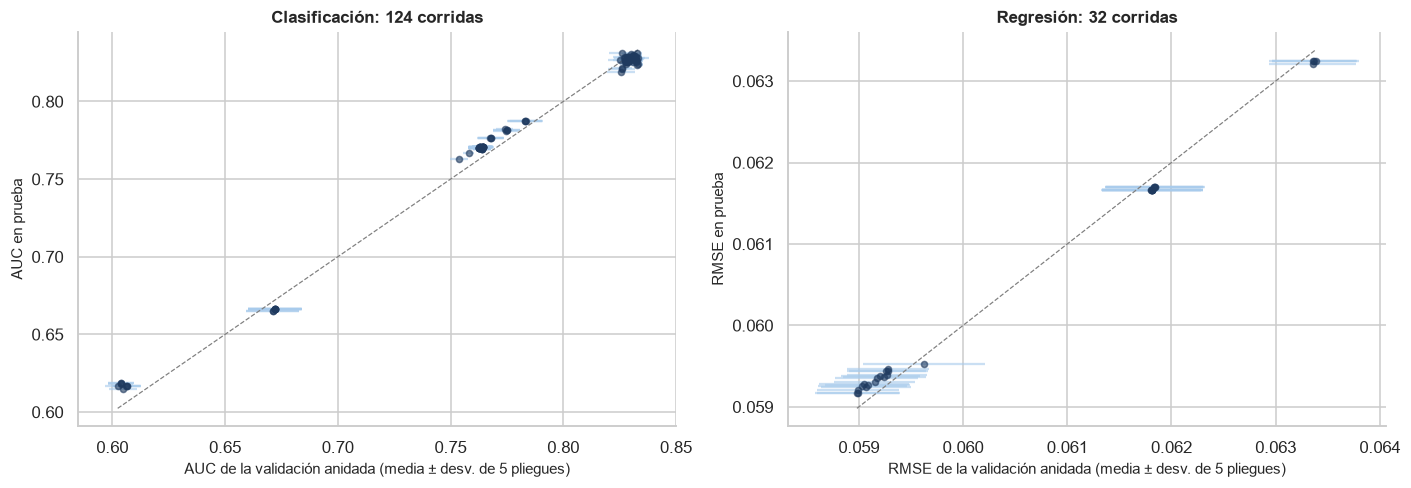


La validación anidada predice muy bien el desempeño en prueba: la correlación entre el AUC externo y el
de prueba es 0,9968 sobre 124 corridas de clasificación, con una
diferencia media de +0,0016; en regresión, la diferencia media de RMSE es
+0,00001. No hay optimismo que corregir: la separación estricta entre la
búsqueda de hiperparámetros (bucle interno) y la estimación (bucle externo) cumplió su función.


In [14]:
todas = metricas.copy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for a, (t, col, nombre) in zip(ax, (('clasificacion', 'auc', 'AUC'), ('regresion', 'rmse', 'RMSE'))):
    sub = todas[todas['tarea'] == t]
    a.errorbar(sub['metrica_cv'], sub[col], xerr=sub['desv_cv'], fmt='o', ms=4, alpha=0.6, color=graficos.AZUL,
               ecolor='#a8cbec')
    lim = [min(sub['metrica_cv'].min(), sub[col].min()), max(sub['metrica_cv'].max(), sub[col].max())]
    a.plot(lim, lim, ls='--', color='grey', lw=0.8)
    a.set_xlabel(f'{nombre} de la validación anidada (media ± desv. de 5 pliegues)')
    a.set_ylabel(f'{nombre} en prueba')
    a.set_title(f'{graficos.NOMBRE_TAREA[t]}: {len(sub)} corridas')
plt.tight_layout()
plt.show()
sub_c = todas[todas['tarea'] == 'clasificacion']
sub_r = todas[todas['tarea'] == 'regresion']
display(Markdown(f"""
La validación anidada predice muy bien el desempeño en prueba: la correlación entre el AUC externo y el
de prueba es {dec(sub_c[['metrica_cv', 'auc']].corr().iloc[0, 1], 4)} sobre {len(sub_c)} corridas de clasificación, con una
diferencia media de {dec((sub_c['auc'] - sub_c['metrica_cv']).mean(), 4, True)}; en regresión, la diferencia media de RMSE es
{dec((sub_r['rmse'] - sub_r['metrica_cv']).mean(), 5, True)}. No hay optimismo que corregir: la separación estricta entre la
búsqueda de hiperparámetros (bucle interno) y la estimación (bucle externo) cumplió su función.
"""))

### Sensibilidad a las semillas

Se reentrenan los modelos finales de Random Forest, XGBoost, SVM y la EBM con distintas semillas (la
del modelo y, si lo hay, la del muestreador; los datos no cambian), y se repite la búsqueda del árbol de
decisión con cinco semillas de cada optimizador estocástico.

In [15]:
if (COMPLEMENTOS / 'semillas.csv').exists():
    sem = pd.read_csv(COMPLEMENTOS / 'semillas.csv')
    sem['modelo'] = sem['modelo'].map(NOMBRES_MODELO)
    resumen_sem = sem.groupby(['tarea', 'modelo']).agg(
        semillas=('semilla', 'size'), auc_media=('auc', 'mean'), auc_desv=('auc', 'std'),
        rmse_media=('rmse', 'mean'), rmse_desv=('rmse', 'std'))
    display(resumen_sem)
    sc = resumen_sem.xs('clasificacion')
    brecha = m_clf['auc'].sort_values(ascending=False)
    display(Markdown(f"""
La desviación del AUC de prueba entre semillas es de {dec(sc['auc_desv'].min(), 4)} a {dec(sc['auc_desv'].max(), 4)}.
{('El SVM lineal no cambia con la semilla: su solucionador primal es determinista. ' if (sc.loc['SVM lineal', 'auc_desv'] if 'SVM lineal' in sc.index else 1) < 1e-9 else '')}La diferencia entre
los dos mejores modelos en prueba ({brecha.index[0]} y {brecha.index[1]}) es de {dec(brecha.iloc[0] - brecha.iloc[1], 4)}:
{'del mismo orden que la variabilidad por semilla, así que no es una diferencia que deba guiar la elección' if brecha.iloc[0] - brecha.iloc[1] < 3 * sc['auc_desv'].max() else 'mayor que la variabilidad por semilla'}.
"""))
else:
    pendiente('semillas.csv')

semillas  auc_media  auc_desv  rmse_media  \
tarea         modelo                                                     
clasificacion EBM                   5     0.8288    0.0000         NaN   
              Random Forest         5     0.8281    0.0010         NaN   
              SVM lineal           10     0.7706    0.0000         NaN   
              XGBoost              10     0.8282    0.0003         NaN   
regresion     EBM                   5        NaN       NaN      0.0593   
              Random Forest         5        NaN       NaN      0.0593   
              XGBoost              10        NaN       NaN      0.0592   

                             rmse_desv  
tarea         modelo                    
clasificacion EBM                  NaN  
              Random Forest        NaN  
              SVM lineal           NaN  
              XGBoost              NaN  
regresion     EBM               0.0000  
              Random Forest     0.0000  
              XGBoost           0.0000


La desviación del AUC de prueba entre semillas es de 0,0000 a 0,0010.
El SVM lineal no cambia con la semilla: su solucionador primal es determinista. La diferencia entre
los dos mejores modelos en prueba (EBM y XGBoost) es de 0,0006:
del mismo orden que la variabilidad por semilla, así que no es una diferencia que deba guiar la elección.


In [16]:
if (COMPLEMENTOS / 'semillas_optimizadores.csv').exists():
    so = pd.read_csv(COMPLEMENTOS / 'semillas_optimizadores.csv')
    r_so = so.groupby('optimizador').agg(interno_media=('mejor_interno', 'mean'), interno_desv=('mejor_interno', 'std'),
                                          prueba_media=('auc_prueba', 'mean'), prueba_desv=('auc_prueba', 'std'),
                                          segundos=('tiempo_s', 'mean')).reindex(['random', 'bayesiana', 'genetica'])
    display(r_so)
    display(Markdown(f"""
Con el mismo árbol de decisión y los mismos pliegues internos, la semilla del optimizador mueve el AUC
de prueba con una desviación de {dec(r_so.loc['random', 'prueba_desv'], 4)} en Random,
{dec(r_so.loc['bayesiana', 'prueba_desv'], 4)} en la bayesiana y {dec(r_so.loc['genetica', 'prueba_desv'], 4)} en la genética: la
elección de hiperparámetros tiene una componente aleatoria del mismo orden que las diferencias entre
métodos de la sección de optimizadores, lo que refuerza la conclusión de que los métodos terminan
empatados en la métrica final.
"""))
else:
    pendiente('semillas_optimizadores.csv')

,interno_media,interno_desv,prueba_media,prueba_desv,segundos
optimizador,,,,,
random,0.8328,0.0005,0.8252,0.0025,31.2188
bayesiana,0.8329,0.0002,0.8246,0.0022,47.3878
genetica,0.8329,0.0001,0.8243,0.0009,49.4224



Con el mismo árbol de decisión y los mismos pliegues internos, la semilla del optimizador mueve el AUC
de prueba con una desviación de 0,0025 en Random,
0,0022 en la bayesiana y 0,0009 en la genética: la
elección de hiperparámetros tiene una componente aleatoria del mismo orden que las diferencias entre
métodos de la sección de optimizadores, lo que refuerza la conclusión de que los métodos terminan
empatados en la métrica final.
